# Notebook 1 — Setup and Data Overview

Denne notebooken gjør fire ting:

1. Setter opp miljøet i Google Colab
2. Kobler til Google Drive / prosjektmappe
3. Leser inn CheXpert-metadata
4. Lager en første oversikt over datasettet og label-fordelingen

## Hvorfor denne notebooken finnes
Før vi trener modeller, må vi forstå datastrukturen, filstier, labels og fordelingen i datasettet.
Dette gjør resten av prosjektet mer ryddig, reproduserbart og lettere å analysere i rapporten.

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [9]:
!kaggle datasets download -d DATASET_OWNER/DATASET_NAME -p /content

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [10]:
import os
import kagglehub
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [11]:
import zipfile


zip_files = [f for f in os.listdir('/content') if f.endswith('.zip')]
print("Zip files found:", zip_files)

zip_path = f"/content/{zip_files[0]}"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Extraction completed.")

Zip files found: []


IndexError: list index out of range

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ===== Project paths =====
PROJECT_ROOT = Path("/content/drive/MyDrive/DAT255_CheXpert_Project")
SESSION_ROOT = Path("/content/dat255_chexpert")

DIRS = {
    "project_root": PROJECT_ROOT,
    "session_root": SESSION_ROOT,
    "raw_data": SESSION_ROOT / "data" / "raw",
    "processed_data": PROJECT_ROOT / "data" / "processed",
    "cache": PROJECT_ROOT / "data" / "cache",
    "models": PROJECT_ROOT / "models",
    "results": PROJECT_ROOT / "results",
    "figures": PROJECT_ROOT / "figures",
    "reports": PROJECT_ROOT / "reports",
    "notebooks": PROJECT_ROOT / "notebooks",
    "src": PROJECT_ROOT / "src",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

for name, p in DIRS.items():
    print(f"{name}: {p}")

project_root: /content/drive/MyDrive/DAT255_CheXpert_Project
session_root: /content/dat255_chexpert
raw_data: /content/dat255_chexpert/data/raw
processed_data: /content/drive/MyDrive/DAT255_CheXpert_Project/data/processed
cache: /content/drive/MyDrive/DAT255_CheXpert_Project/data/cache
models: /content/drive/MyDrive/DAT255_CheXpert_Project/models
results: /content/drive/MyDrive/DAT255_CheXpert_Project/results
figures: /content/drive/MyDrive/DAT255_CheXpert_Project/figures
reports: /content/drive/MyDrive/DAT255_CheXpert_Project/reports
notebooks: /content/drive/MyDrive/DAT255_CheXpert_Project/notebooks
src: /content/drive/MyDrive/DAT255_CheXpert_Project/src


In [6]:
# ===== Config =====
CONFIG = {
    "seed": 42,
    "image_size": 224,
    "image_channels": 3,
    "num_labels": 14,
    "epochs_baseline": 5,
    "epochs_transfer": 5,
    "learning_rate_head": 1e-3,
    "learning_rate_finetune": 1e-5,
    "project_root": str(DIRS["project_root"]),
    "session_root": str(DIRS["session_root"]),
    "raw_data_root": str(DIRS["raw_data"]),
    "processed_data_root": str(DIRS["processed_data"]),
    "cache_root": str(DIRS["cache"]),
    "models_root": str(DIRS["models"]),
    "results_root": str(DIRS["results"]),
    "figures_root": str(DIRS["figures"]),
    "reports_root": str(DIRS["reports"]),
    "target_labels": [
        "No Finding",
        "Enlarged Cardiomediastinum",
        "Cardiomegaly",
        "Lung Opacity",
        "Lung Lesion",
        "Edema",
        "Consolidation",
        "Pneumonia",
        "Atelectasis",
        "Pneumothorax",
        "Pleural Effusion",
        "Pleural Other",
        "Fracture",
        "Support Devices",
    ],
    "competition_labels": [
        "Atelectasis",
        "Cardiomegaly",
        "Consolidation",
        "Edema",
        "Pleural Effusion",
    ],
}

print(json.dumps(CONFIG, indent=2))

{
  "seed": 42,
  "image_size": 224,
  "image_channels": 3,
  "num_labels": 14,
  "epochs_baseline": 5,
  "epochs_transfer": 5,
  "learning_rate_head": 0.001,
  "learning_rate_finetune": 1e-05,
  "project_root": "/content/drive/MyDrive/DAT255_CheXpert_Project",
  "session_root": "/content/dat255_chexpert",
  "raw_data_root": "/content/dat255_chexpert/data/raw",
  "processed_data_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/data/processed",
  "cache_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/data/cache",
  "models_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/models",
  "results_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/results",
  "figures_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/figures",
  "reports_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/reports",
  "target_labels": [
    "No Finding",
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
 

In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API configured.")

In [ ]:
DATASET_ROOT = "/content/CheXpert-v1.0-small"
print("Dataset exists:", os.path.exists(DATASET_ROOT))

In [ ]:
# ===== Download / locate CheXpert =====
def ensure_chexpert_dataset(raw_data_root: Path):
    raw_data_root = Path(raw_data_root)
    train_csv = raw_data_root / "train.csv"
    valid_csv = raw_data_root / "valid.csv"

    if train_csv.exists() and valid_csv.exists():
        print("CheXpert already available at:", raw_data_root)
        return raw_data_root

    print("CheXpert not found locally. Downloading from KaggleHub...")
    downloaded_path = Path(kagglehub.dataset_download("ashery/chexpert"))
    print("Downloaded to:", downloaded_path)

    # Finn mappen som faktisk inneholder train.csv
    if (downloaded_path / "train.csv").exists():
        source_root = downloaded_path
    else:
        candidates = list(downloaded_path.rglob("train.csv"))
        if not candidates:
            raise FileNotFoundError("Could not find train.csv in downloaded dataset.")
        source_root = candidates[0].parent

    print("Using source root:", source_root)

    raw_data_root.mkdir(parents=True, exist_ok=True)

    # Hvis raw_data_root er tom, lag symbolsk lenke til datasettet
    # Dette er mye raskere enn å kopiere alt.
    for item in source_root.iterdir():
        target = raw_data_root / item.name
        if target.exists():
            continue
        try:
            os.symlink(item, target)
        except Exception:
            # fallback hvis symlink feiler
            if item.is_dir():
                import shutil
                shutil.copytree(item, target)
            else:
                import shutil
                shutil.copy2(item, target)

    if not train_csv.exists() or not valid_csv.exists():
        raise FileNotFoundError("train.csv / valid.csv not found after setup.")

    print("CheXpert ready at:", raw_data_root)
    return raw_data_root


DATA_ROOT = ensure_chexpert_dataset(CONFIG["raw_data_root"])
print("DATA_ROOT =", DATA_ROOT)

CheXpert not found locally. Downloading from KaggleHub...


100%|██████████| 10.7G/10.7G [02:10<00:00, 88.3MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/ashery/chexpert/versions/1
Using source root: /root/.cache/kagglehub/datasets/ashery/chexpert/versions/1
CheXpert ready at: /content/dat255_chexpert/data/raw
DATA_ROOT = /content/dat255_chexpert/data/raw


## Enkel inspeksjon av datastrukturen

In [ ]:
print("Top-level contents of DATA_ROOT:")
for item in sorted(DATA_ROOT.iterdir()):
    print("-", item.name)

Top-level contents of DATA_ROOT:
- train
- train.csv
- valid
- valid.csv


## Får en representasjon av datasettet

In [ ]:
train_df = pd.read_csv(DATA_ROOT / "train.csv")
valid_df = pd.read_csv(DATA_ROOT / "valid.csv")

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

train_df.head()

Train shape: (223414, 19)
Valid shape: (234, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


## Første datainspeksjon

Vi ser først på kolonner, datatyper og hvor mange manglende verdier som finnes.
Dette er viktig fordi CheXpert inneholder både eksplisitte labels og blanke felt.

In [ ]:
print("Columns:")
display(pd.DataFrame({
    "column": train_df.columns,
    "dtype": [str(train_df[col].dtype) for col in train_df.columns],
    "missing_values": [train_df[col].isna().sum() for col in train_df.columns]
}))

Columns:


,column,dtype,missing_values
0,Path,object,0
1,Sex,object,0
2,Age,int64,0
3,Frontal/Lateral,object,0
4,AP/PA,object,32387
5,No Finding,float64,201033
6,Enlarged Cardiomediastinum,float64,178575
7,Cardiomegaly,float64,177211
8,Lung Opacity,float64,105636
9,Lung Lesion,float64,211470


In [ ]:
train_df.sample(5, random_state=SEED)

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
305,CheXpert-v1.0-small/train/patient00082/study1/...,Male,18,Frontal,PA,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
151324,CheXpert-v1.0-small/train/patient35759/study9/...,Male,90,Frontal,AP,NaN,NaN,1.0,NaN,NaN,1.0,-1.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0
19284,CheXpert-v1.0-small/train/patient04789/study1/...,Male,39,Lateral,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
165026,CheXpert-v1.0-small/train/patient38491/study5/...,Male,60,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
26786,CheXpert-v1.0-small/train/patient06537/study3/...,Female,66,Frontal,AP,NaN,NaN,0.0,1.0,NaN,NaN,0.0,-1.0,-1.0,0.0,0.0,NaN,NaN,NaN


## Definer label-kolonnene eksplisitt

In [ ]:
LABEL_COLUMNS = CONFIG["target_labels"]
META_COLUMNS = [col for col in train_df.columns if col not in LABEL_COLUMNS]

print("Metadata columns:")
print(META_COLUMNS)

print("\nLabel columns:")
print(LABEL_COLUMNS)

Metadata columns:
['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA']

Label columns:
['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


## Om CheXpert-labelene

CheXpert bruker følgende label-logikk i metadata:

- `1` = positiv observasjon
- `0` = negativ observasjon
- `-1` = uncertain
- blank / NaN = ikke nevnt / manglende label

Dette er viktig for prosjektet fordi multi-label klassifisering ikke bare handler om sykdom vs. ikke sykdom,
men også om hvordan vi velger å håndtere uncertain labels.

In [ ]:
label_summary = []

for col in LABEL_COLUMNS:
    values = train_df[col]
    label_summary.append({
        "label": col,
        "num_positive_1": (values == 1).sum(),
        "num_negative_0": (values == 0).sum(),
        "num_uncertain_-1": (values == -1).sum(),
        "num_missing_nan": values.isna().sum(),
    })

label_summary_df = pd.DataFrame(label_summary)
label_summary_df

,label,num_positive_1,num_negative_0,num_uncertain_-1,num_missing_nan
0,No Finding,22381,0,0,201033
1,Enlarged Cardiomediastinum,10798,21638,12403,178575
2,Cardiomegaly,27000,11116,8087,177211
3,Lung Opacity,105581,6599,5598,105636
4,Lung Lesion,9186,1270,1488,211470
5,Edema,52246,20726,12984,137458
6,Consolidation,14783,28097,27742,152792
7,Pneumonia,6039,2799,18770,195806
8,Atelectasis,33376,1328,33739,154971
9,Pneumothorax,19448,56341,3145,144480


## Sidenote - Fjern etterpå
Dette er gull for rapportens Data-seksjon. Rapportmalen ber dere beskrive data, fordeler/ulemper og eventuell omformatering. Denne analysen gir dere akkurat den historien.
Prosjektrapport DAT255-1

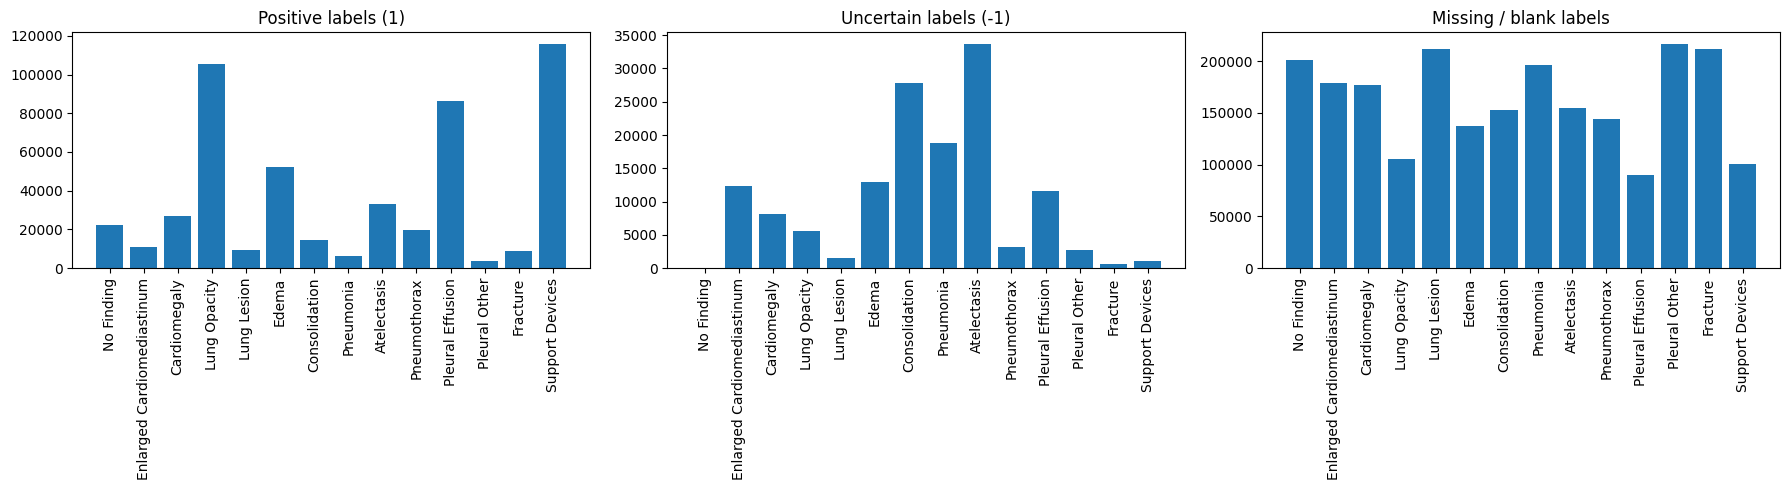

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(label_summary_df["label"], label_summary_df["num_positive_1"])
axes[0].set_title("Positive labels (1)")
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(label_summary_df["label"], label_summary_df["num_uncertain_-1"])
axes[1].set_title("Uncertain labels (-1)")
axes[1].tick_params(axis='x', rotation=90)

axes[2].bar(label_summary_df["label"], label_summary_df["num_missing_nan"])
axes[2].set_title("Missing / blank labels")
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## View-position og metadataanalyse

In [ ]:
if "Frontal/Lateral" in train_df.columns:
    print(train_df["Frontal/Lateral"].value_counts(dropna=False))

if "AP/PA" in train_df.columns:
    print(train_df["AP/PA"].value_counts(dropna=False))

Frontal/Lateral
Frontal    191027
Lateral     32387
Name: count, dtype: int64
AP/PA
AP     161590
NaN     32387
PA      29420
LL         16
RL          1
Name: count, dtype: int64


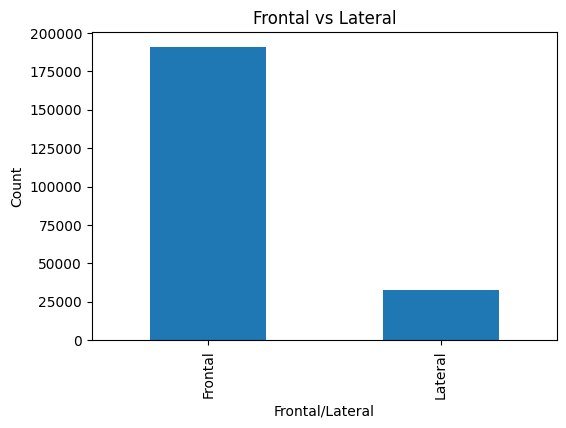

In [ ]:
if "Frontal/Lateral" in train_df.columns:
    train_df["Frontal/Lateral"].value_counts(dropna=False).plot(kind="bar", figsize=(6,4))
    plt.title("Frontal vs Lateral")
    plt.ylabel("Count")
    plt.show()

In [ ]:
train_df["Path"].head()

,Path
0,CheXpert-v1.0-small/train/patient00001/study1/...
1,CheXpert-v1.0-small/train/patient00002/study2/...
2,CheXpert-v1.0-small/train/patient00002/study1/...
3,CheXpert-v1.0-small/train/patient00002/study1/...
4,CheXpert-v1.0-small/train/patient00003/study1/...


In [ ]:
def make_image_path(path_str, data_root):
    path_str = str(path_str).replace("CheXpert-v1.0-small/", "")
    return Path(data_root) / path_str

sample_paths = train_df["Path"].dropna().sample(5, random_state=SEED).tolist()

for p in sample_paths:
    full_path = make_image_path(p, DATA_ROOT)
    print(full_path, "->", full_path.exists())

/content/dat255_chexpert/data/raw/train/patient00082/study1/view1_frontal.jpg -> True
/content/dat255_chexpert/data/raw/train/patient35759/study9/view1_frontal.jpg -> True
/content/dat255_chexpert/data/raw/train/patient04789/study1/view2_lateral.jpg -> True
/content/dat255_chexpert/data/raw/train/patient38491/study5/view1_frontal.jpg -> True
/content/dat255_chexpert/data/raw/train/patient06537/study3/view1_frontal.jpg -> True


## Eksempelbilder

Vi viser noen tilfeldige bilder fra treningssettet for å kontrollere at:
- filstiene fungerer riktig
- bildene kan åpnes uten feil
- datasettet faktisk ser ut som forventet

Dette er også nyttig for å få en intuitiv forståelse av bildedataene før preprocessing.

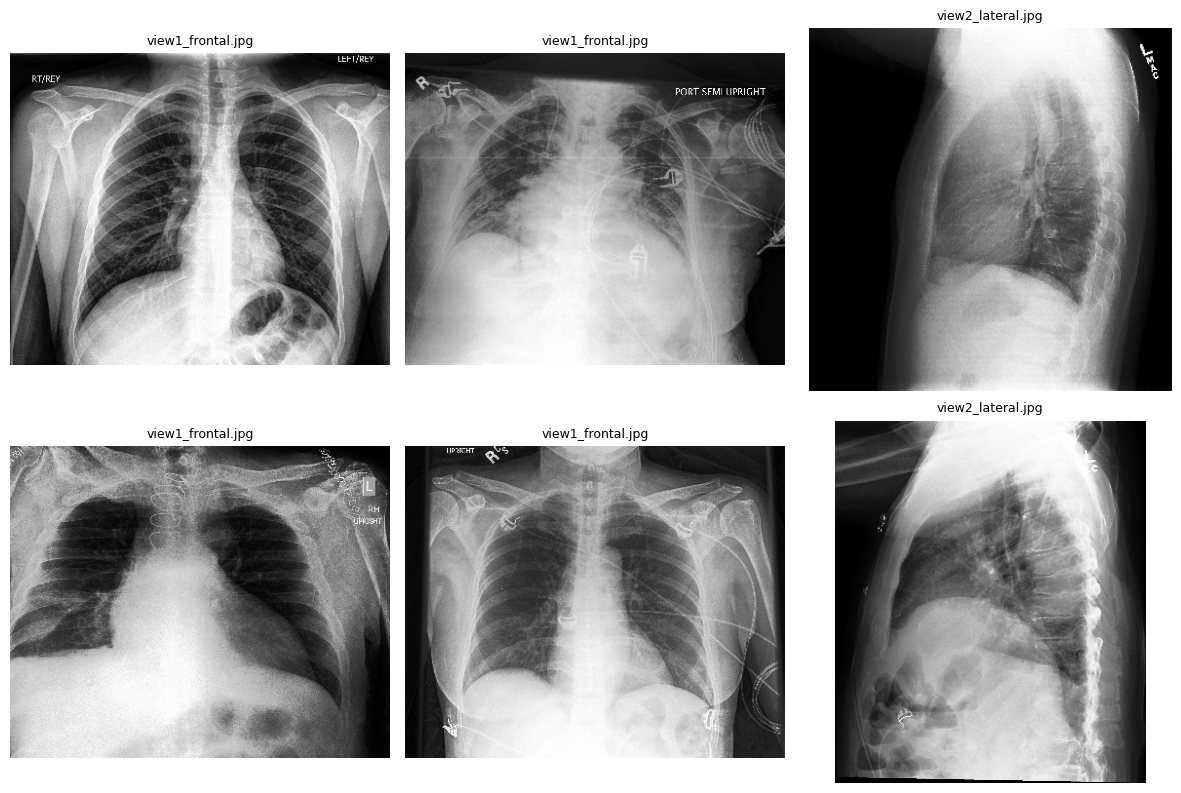

In [ ]:
sample_df = train_df.dropna(subset=["Path"]).sample(6, random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img_path = make_image_path(row["Path"], DATA_ROOT)
    img = Image.open(img_path)

    ax.imshow(img, cmap="gray")
    ax.set_title(Path(row["Path"]).name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Eksempelbilder med labels

Her viser vi noen tilfeldige bilder sammen med positive labels.
Målet er ikke å verifisere medisinske diagnoser manuelt, men å forstå hvordan metadataene ser ut i praksis.

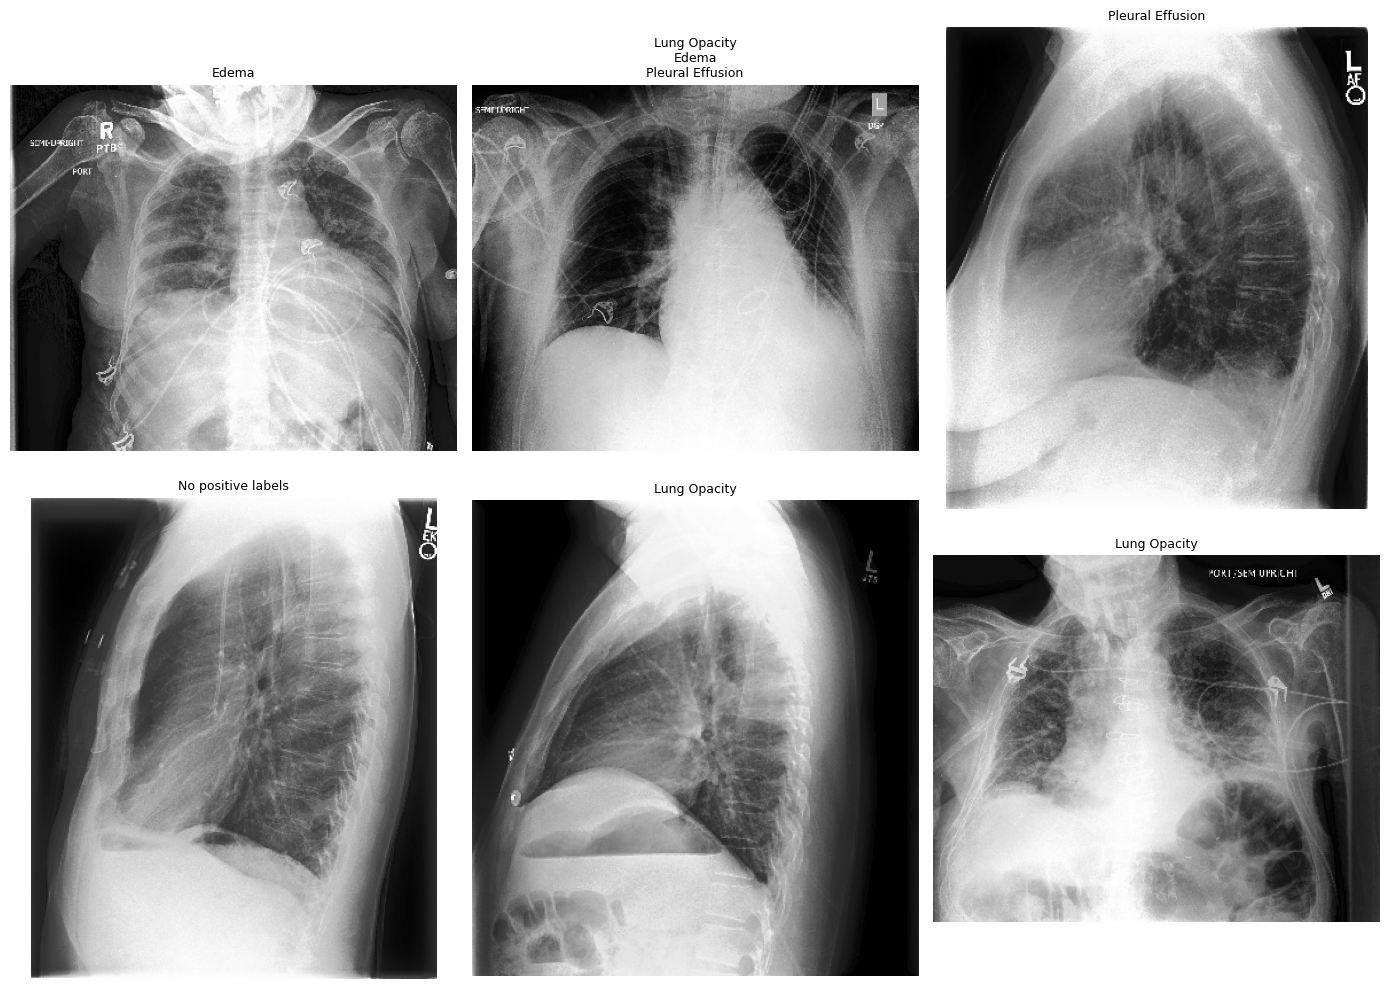

In [ ]:
sample_df = train_df.dropna(subset=["Path"]).sample(6, random_state=123)

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img_path = make_image_path(row["Path"], DATA_ROOT)
    img = Image.open(img_path)

    positive_labels = [label for label in LABEL_COLUMNS if row[label] == 1]
    title_text = "\n".join(positive_labels[:3]) if positive_labels else "No positive labels"

    ax.imshow(img, cmap="gray")
    ax.set_title(title_text, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Bildestørrelser

Før vi bestemmer preprocessing og input-størrelse for modellen, undersøker vi et utvalg bildestørrelser.
Dette hjelper oss å begrunne hvorfor vi senere resizer bildene til en fast størrelse, for eksempel 224x224.

In [ ]:
image_sizes = []

for p in train_df["Path"].dropna().sample(50, random_state=SEED):
    img_path = make_image_path(p, DATA_ROOT)
    with Image.open(img_path) as img:
        image_sizes.append(img.size)

size_df = pd.DataFrame(image_sizes, columns=["width", "height"])
size_df.describe()

,width,height
count,50.00000,50.000000
mean,368.98000,325.860000
std,31.60308,16.587443
min,320.00000,320.000000
25%,320.00000,320.000000
50%,390.00000,320.000000
75%,390.00000,320.000000
max,390.00000,390.000000


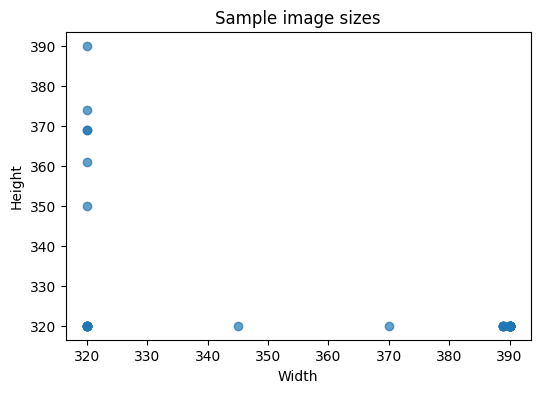

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(size_df["width"], size_df["height"], alpha=0.7)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Sample image sizes")
plt.show()

In [ ]:
size_df.head()

,width,height
0,390,320
1,390,320
2,320,320
3,390,320
4,390,320


## Kontroll av lesbare bildefiler

Vi tester et lite tilfeldig utvalg for å kontrollere at bildefilene kan åpnes uten feil.

In [ ]:
bad_files = []

sample_paths = train_df["Path"].dropna().sample(100, random_state=SEED)

for p in sample_paths:
    img_path = make_image_path(p, DATA_ROOT)
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception as e:
        bad_files.append((str(img_path), str(e)))

print("Number of unreadable files in sample:", len(bad_files))

if bad_files:
    print("Example bad file:", bad_files[0])

Number of unreadable files in sample: 0


## Hvor mange positive labels har hvert bilde?

Siden dette er et multi-label problem, kan ett bilde ha flere positive observasjoner samtidig.
Vi undersøker derfor hvor mange positive labels hvert bilde typisk har.

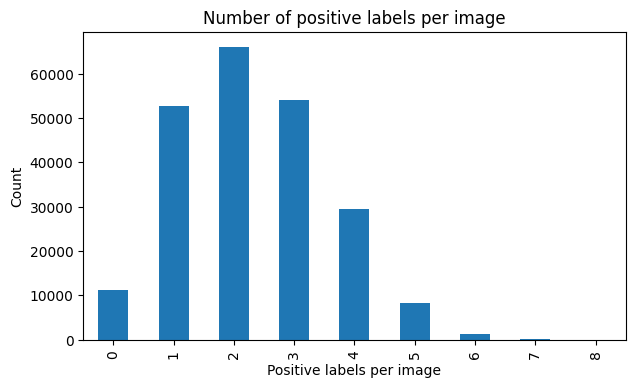

,0
count,223414.000000
mean,2.307774
std,1.245450
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,8.000000


In [ ]:
train_positive_counts = (train_df[LABEL_COLUMNS] == 1).sum(axis=1)

plt.figure(figsize=(7, 4))
train_positive_counts.value_counts().sort_index().plot(kind="bar")
plt.title("Number of positive labels per image")
plt.xlabel("Positive labels per image")
plt.ylabel("Count")
plt.show()
train_positive_counts.describe()

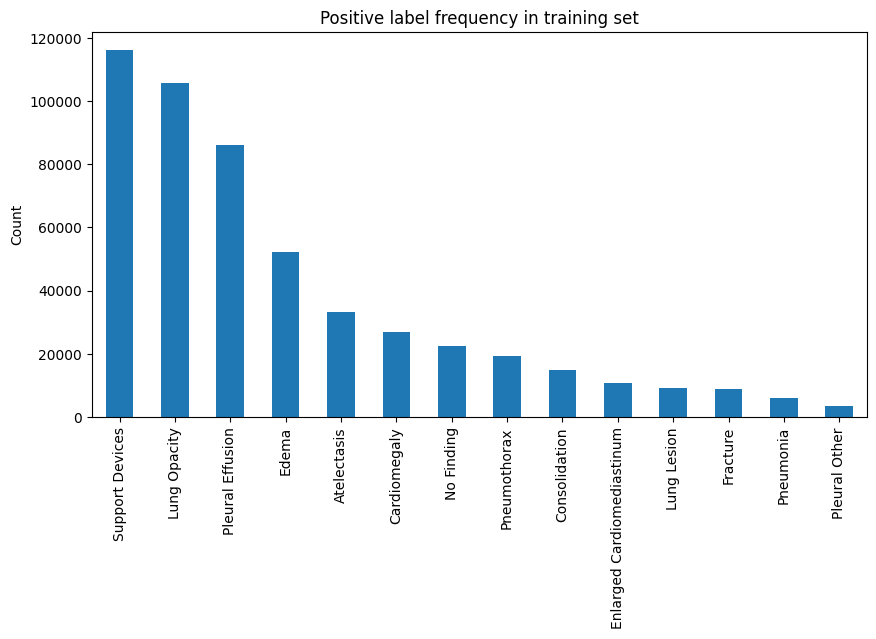

,0
Support Devices,116001
Lung Opacity,105581
Pleural Effusion,86187
Edema,52246
Atelectasis,33376
Cardiomegaly,27000
No Finding,22381
Pneumothorax,19448
Consolidation,14783
Enlarged Cardiomediastinum,10798


In [ ]:
positive_counts = (train_df[LABEL_COLUMNS] == 1).sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
positive_counts.plot(kind="bar")
plt.title("Positive label frequency in training set")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

positive_counts

## Uncertain labels

CheXpert inneholder også uncertain labels (`-1`), som er en sentral del av datasettet.
Vi undersøker hvor ofte disse forekommer for hver observasjon.

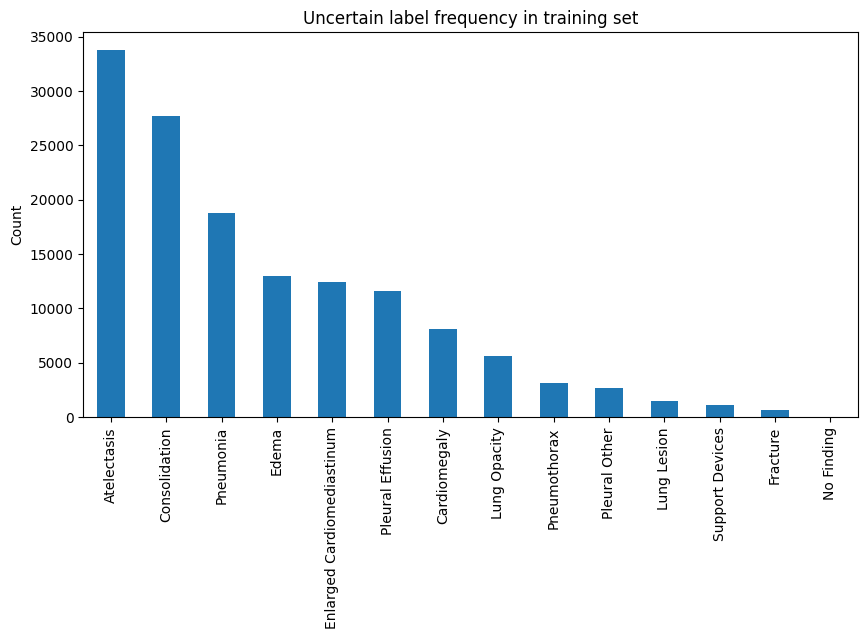

,0
Atelectasis,33739
Consolidation,27742
Pneumonia,18770
Edema,12984
Enlarged Cardiomediastinum,12403
Pleural Effusion,11628
Cardiomegaly,8087
Lung Opacity,5598
Pneumothorax,3145
Pleural Other,2653


In [ ]:
uncertain_counts = (train_df[LABEL_COLUMNS] == -1).sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
uncertain_counts.plot(kind="bar")
plt.title("Uncertain label frequency in training set")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

uncertain_counts

## Sammenligning mellom train og validation

Vi sammenligner fordelingen av positive labels i train- og validation-settene for å se om de ser rimelig konsistente ut.

In [ ]:
train_pos = (train_df[LABEL_COLUMNS] == 1).sum()
valid_pos = (valid_df[LABEL_COLUMNS] == 1).sum()

compare_df = pd.DataFrame({
    "train_positive": train_pos,
    "valid_positive": valid_pos
})

compare_df

,train_positive,valid_positive
No Finding,22381,38
Enlarged Cardiomediastinum,10798,109
Cardiomegaly,27000,68
Lung Opacity,105581,126
Lung Lesion,9186,1
Edema,52246,45
Consolidation,14783,33
Pneumonia,6039,8
Atelectasis,33376,80
Pneumothorax,19448,8


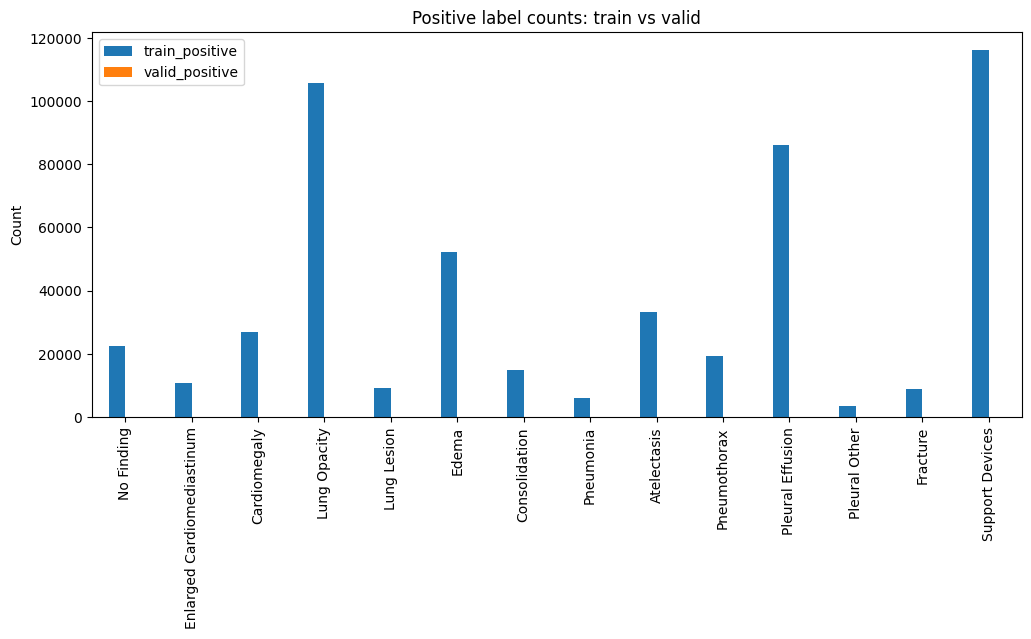

In [ ]:
compare_df.plot(kind="bar", figsize=(12, 5))
plt.title("Positive label counts: train vs valid")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

## Første observasjoner om datasettet

Basert på analysen så langt ser vi at:

- CheXpert er et multi-label datasett
- klassene er tydelig ubalanserte
- uncertain labels forekommer ofte
- noen labels har mange manglende verdier
- bildene må standardiseres til en fast input-størrelse
- metadata og bildefiler kan kobles sammen pålitelig med riktig path-håndtering

Dette betyr at neste notebook bør fokusere på:
1. label cleaning
2. definisjon av uncertainty-strategi
3. preprocessing
4. bygging av en effektiv `tf.data` pipeline

# Lagring i disken

In [ ]:
results_root = Path(CONFIG["results_root"])

label_summary_df.to_csv(results_root / "label_summary_notebook1.csv", index=False)
size_df.to_csv(results_root / "sample_image_sizes_notebook1.csv", index=False)
compare_df.to_csv(results_root / "train_valid_positive_comparison_notebook1.csv", index=True)

print("Saved summary tables to:", results_root)

Saved summary tables to: /content/drive/MyDrive/DAT255_CheXpert_Project/results


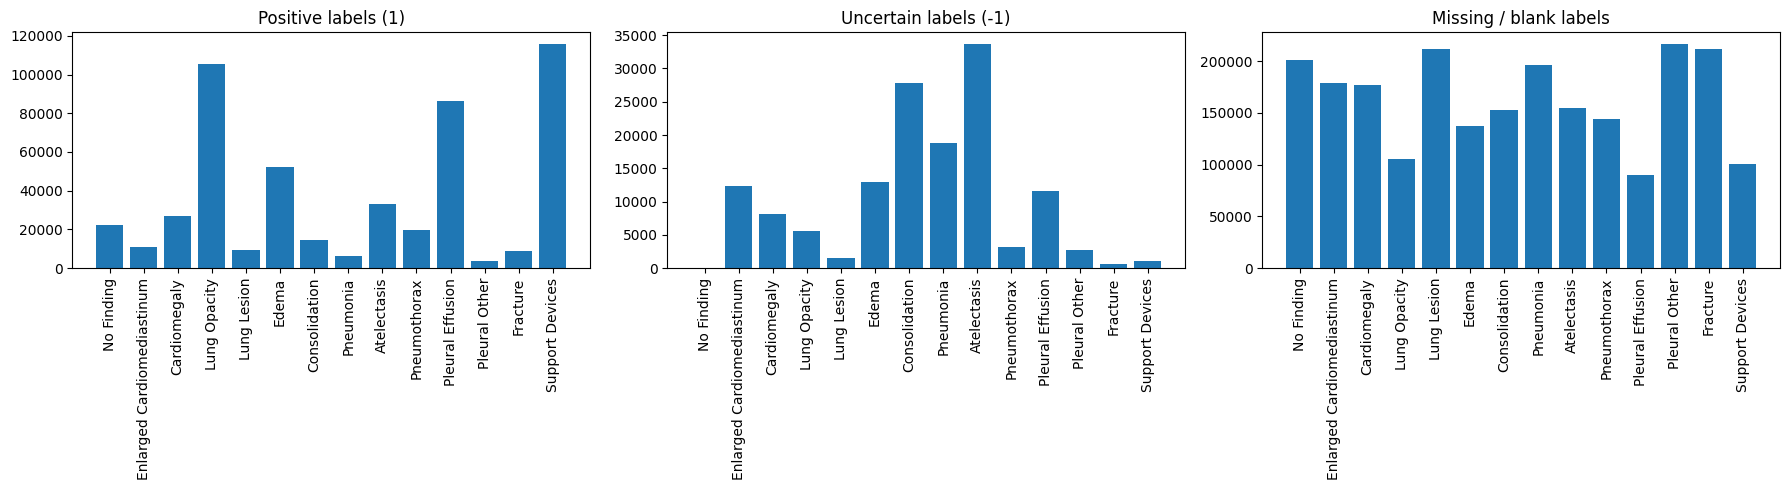

In [ ]:
figures_root = Path(CONFIG["figures_root"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(label_summary_df["label"], label_summary_df["num_positive_1"])
axes[0].set_title("Positive labels (1)")
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(label_summary_df["label"], label_summary_df["num_uncertain_-1"])
axes[1].set_title("Uncertain labels (-1)")
axes[1].tick_params(axis='x', rotation=90)

axes[2].bar(label_summary_df["label"], label_summary_df["num_missing_nan"])
axes[2].set_title("Missing / blank labels")
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(figures_root / "label_distribution_notebook1.png", dpi=200, bbox_inches="tight")
plt.show()

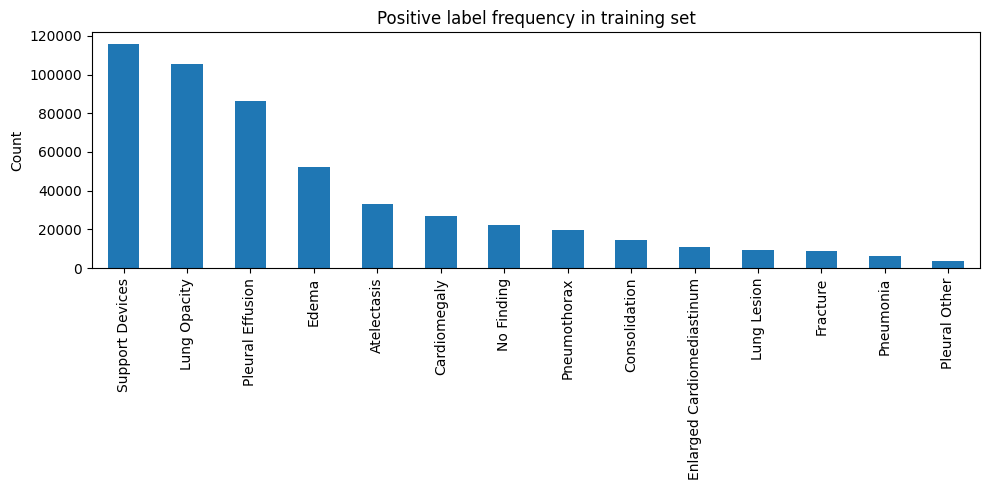

In [ ]:
plt.figure(figsize=(10, 5))
positive_counts.plot(kind="bar")
plt.title("Positive label frequency in training set")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(Path(CONFIG["figures_root"]) / "positive_label_frequency_notebook1.png", dpi=200, bbox_inches="tight")
plt.show()

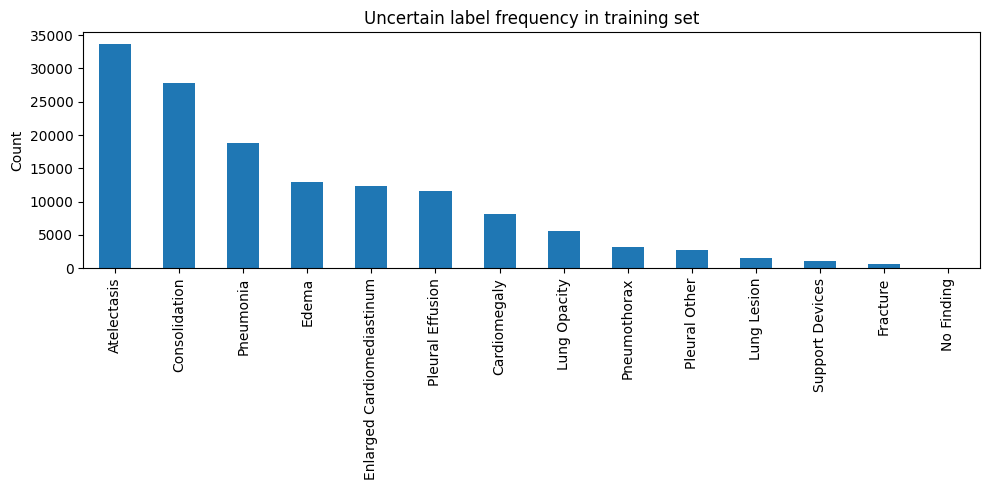

In [ ]:
plt.figure(figsize=(10, 5))
uncertain_counts.plot(kind="bar")
plt.title("Uncertain label frequency in training set")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(Path(CONFIG["figures_root"]) / "uncertain_label_frequency_notebook1.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
config_path = Path(CONFIG["results_root"]) / "config.json"

with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Config saved to:", config_path)

Config saved to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/config.json


## Konklusjon

I denne notebooken har vi:
- satt opp prosjektmiljøet i Colab
- lest inn CheXpert-metadata
- koblet metadata til faktiske bildefiler
- undersøkt label-fordeling, uncertain labels og bildestørrelser
- bekreftet at datasettet er klart for neste steg i prosjektet

Neste notebook skal fokusere på preprocessing og label-håndtering, slik at vi kan bygge en robust input-pipeline for modelltrening.